In [ ]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=0

env: CUDA_VISIBLE_DEVICES=0


In [ ]:
import torch
import argparse
import asyncio
import datetime
import os, random
import numpy as np
import pandas as pd
from torch.utils.data import Subset
from data.load_data import load_nako
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from openTSNE import TSNE
from omegaconf import OmegaConf
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, accuracy_score, ConfusionMatrixDisplay
from multi_level_split.util import train_test_split as patient_id_split
from utils import linear_acc
from linear_probe_utils import NAKOBase, extract_embeddings


import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import matplotlib as mpl
from nako import NakoDataset, get_nako_paths, IMAGE_TYPES, EYE_DISEASES
import json

torch.set_float32_matmul_precision('medium')
random.seed(2024)

In [3]:
config_file = '.secrets.yaml'
cfg = OmegaConf.load(config_file)
dataset_root = cfg['DATASETS']['NAKO']['mlcloud']
dataset_root

'/home/berens/bep973/ifeoma_home/data/NAKO'

## Create data

In [4]:
labels_df = pd.read_csv(os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv'))
labels_df.head()

/tmp/ipykernel_2577238/1976496445.py:1: DtypeWarning: Columns (0: rt_rightnasal_3_date, 1: rt_rightcent_3_date, 2: rt_leftnasal_3_date, 3: rt_leftcent_3_date) have mixed types. Specify dtype option on import or set low_memory=False.
  labels_df = pd.read_csv(os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv'))


,ID,tgr_nako,tgr_nako_df100k,basis_sex,basis_age,basis_ageclass,basis_lvl,a_ethn1,a_ethn2,a_ses_mig_status,...,d_rtbf_lve_dia_calch,d_rtbf_lve_ghost,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort
0,100000,1,2,2,61,60,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81
1,100001,1,1,2,53,50,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,811
2,100002,1,2,1,42,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,12
3,100003,1,2,1,34,30,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,33
4,100004,1,2,2,41,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.0,23


In [5]:
LABELS_FILE = os.path.join(dataset_root, 'NAKO_metadata','labels', 'labels.csv')
METADATA_FILE = f'{dataset_root}/NAKO_metadata/labels/metadata_translated.csv'

In [6]:
decoder = nako.FeatureDecoder(os.path.join(LABELS_FILE, METADATA_FILE))


In [7]:
colors = sns.color_palette('pastel', 10)
colors = cycle([mpl.colors.rgb2hex(c) for c in colors])

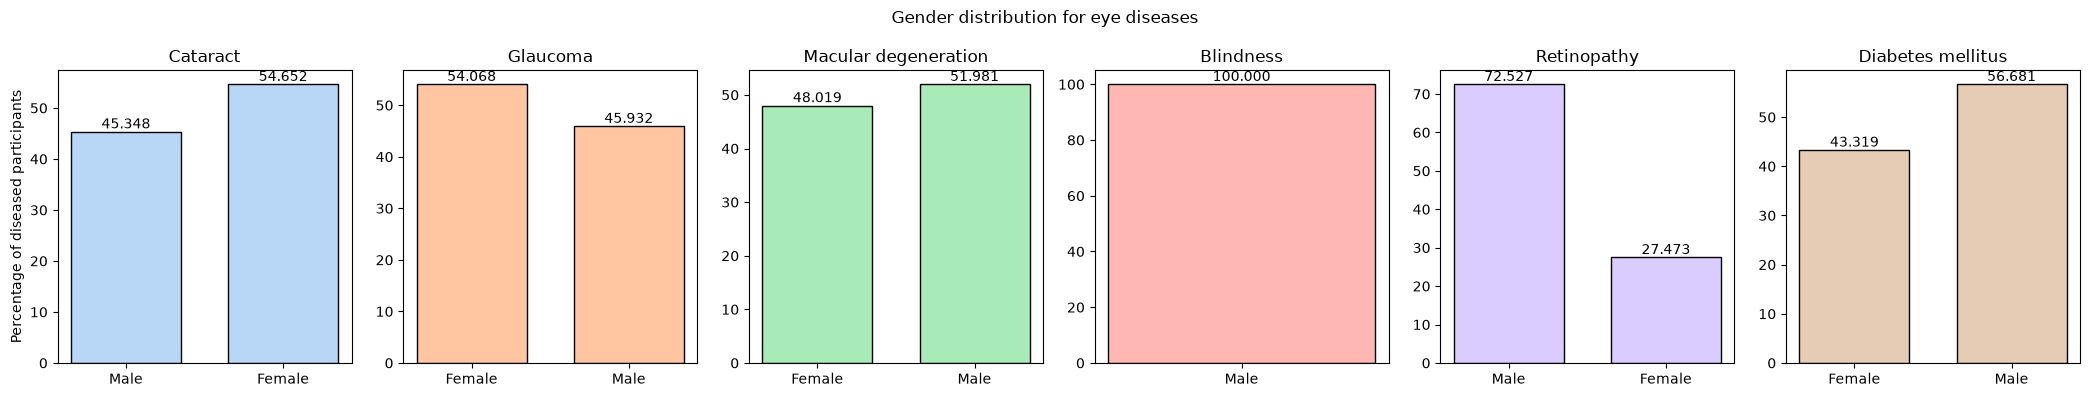

In [8]:
feature_names = [ 'basis_sex'] + EYE_DISEASES
df = labels_df[feature_names].copy()

feature_name = feature_names[0]
mapping, label = decoder.decode(feature_name)
df, mapping = decoder.group_nans(feature_name, mapping, df)
df[feature_name] = df[feature_name].map(mapping)

fig, ax = plt.subplots(1, 6, figsize=(21, 4))

for i, feature_name in enumerate(feature_names[1:]):
    mapping, label = decoder.decode(feature_name)
    df, mapping = decoder.group_nans(feature_name, mapping, df)
    df[feature_name] = df[feature_name].map(mapping)
    # print(df[feature_name].value_counts(dropna = False))
    df_filtered = df[df[feature_name] == 'Yes']
    sns.histplot(x='basis_sex', data=df_filtered, stat='percent', shrink=0.7, color=next(colors), ax=ax[i])

    ax[i].bar_label(ax[i].containers[0], fmt='%.3f')
    ax[i].set_title(label.capitalize())
    ax[i].set_xlabel('')
    ax[i].set_ylabel('')
    
ax[0].set_ylabel('Percentage of diseased participants')
fig.suptitle('Gender distribution for eye diseases')
plt.tight_layout()

In [9]:
df.head(1)

,basis_sex,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,Female,No,No,No,Missing,Missing,No


In [10]:
labels_df['d_an_aug_1'].value_counts(dropna = False)

d_an_aug_1
2.0       46297
1.0        2042
9999.0      100
NaN          18
8888.0        3
Name: count, dtype: int64

In [11]:
labels_df['d_an_aug_2'].value_counts(dropna = False)

d_an_aug_2
2.0       47338
1.0         971
9999.0      130
NaN          18
8888.0        3
Name: count, dtype: int64

In [12]:
labels_df['d_an_aug_3'].value_counts(dropna = False)

d_an_aug_3
2.0       47870
1.0         429
9999.0      140
NaN          18
8888.0        3
Name: count, dtype: int64

In [13]:
labels_df['d_an_metdm2c_2'].value_counts(dropna = False)

d_an_metdm2c_2
NaN       46080
2.0        2373
8888.0        5
1.0           1
9999.0        1
Name: count, dtype: int64

In [14]:
labels_df['d_an_metdm2c_1'].value_counts(dropna = False)

d_an_metdm2c_1
NaN       46080
2.0        2240
1.0          91
9999.0       44
8888.0        5
Name: count, dtype: int64

In [15]:
labels_df['d_an_met_1'].value_counts(dropna = False)

d_an_met_1
2.0       46016
1.0        2380
9999.0       51
NaN          10
8888.0        3
Name: count, dtype: int64

In [16]:
EYE_DISEASES

['d_an_aug_1',
 'd_an_aug_2',
 'd_an_aug_3',
 'd_an_metdm2c_2',
 'd_an_metdm2c_1',
 'd_an_met_1']

In [17]:
labels_df[['ID']+ EYE_DISEASES]

,ID,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,100000,2.0,2.0,2.0,NaN,NaN,2.0
1,100001,2.0,2.0,2.0,NaN,NaN,2.0
2,100002,2.0,2.0,2.0,NaN,NaN,2.0
3,100003,2.0,2.0,2.0,NaN,NaN,2.0
4,100004,2.0,2.0,2.0,NaN,NaN,2.0
...,...,...,...,...,...,...,...
48455,148458,2.0,2.0,2.0,NaN,NaN,2.0
48456,148459,2.0,2.0,2.0,2.0,2.0,1.0
48457,148460,2.0,2.0,2.0,NaN,NaN,2.0
48458,148461,2.0,2.0,2.0,NaN,NaN,2.0


In [ ]:
labels_df[EYE_DISEASES] = labels_df[EYE_DISEASES].fillna('nan val').astype(int)


In [21]:
labels_df[EYE_DISEASES]

,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,2,2,2,100,100,2
1,2,2,2,100,100,2
2,2,2,2,100,100,2
3,2,2,2,100,100,2
4,2,2,2,100,100,2
...,...,...,...,...,...,...
48455,2,2,2,100,100,2
48456,2,2,2,2,2,1
48457,2,2,2,100,100,2
48458,2,2,2,100,100,2


In [22]:
labels_df[EYE_DISEASES].replace([9999.0, 8888.0], ['dont_know', 'no_idea'])

,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,2,2,2,100,100,2
1,2,2,2,100,100,2
2,2,2,2,100,100,2
3,2,2,2,100,100,2
4,2,2,2,100,100,2
...,...,...,...,...,...,...
48455,2,2,2,100,100,2
48456,2,2,2,2,2,1
48457,2,2,2,100,100,2
48458,2,2,2,100,100,2


In [23]:
has_1_or_2 = labels_df[EYE_DISEASES].isin([1, 2]).any(axis=1)
labels_df['all_unknown'] = (~has_1_or_2).astype(int)
labels_df['all_unknown'].value_counts(dropna = False)

all_unknown
0    48449
Name: count, dtype: int64

In [24]:
print(labels_df.shape)
labels_df = labels_df[labels_df['all_unknown'] == 0]
print(labels_df.shape)


(48449, 549)
(48449, 549)


In [25]:
labels_df['any_eye_disease'] = (labels_df[EYE_DISEASES] == 1).any(axis=1).astype(int)
labels_df['any_eye_disease'].value_counts(dropna = False)

/tmp/ipykernel_2577238/2215720965.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  labels_df['any_eye_disease'] = (labels_df[EYE_DISEASES] == 1).any(axis=1).astype(int)


any_eye_disease
0    43347
1     5102
Name: count, dtype: int64

In [26]:
labels_df.head()

,ID,tgr_nako,tgr_nako_df100k,basis_sex,basis_age,basis_ageclass,basis_lvl,a_ethn1,a_ethn2,a_ses_mig_status,...,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort,all_unknown,any_eye_disease
0,100000,1,2,2,61,60,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81,0,0
1,100001,1,1,2,53,50,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,811,0,0
2,100002,1,2,1,42,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,12,0,0
3,100003,1,2,1,34,30,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,33,0,0
4,100004,1,2,2,41,40,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,23,0,0


In [27]:
mapping_df = pd.read_csv(os.path.join(dataset_root, 'images_lowres', 'mapping.csv'))
mapping_df.head()

,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal
0,100000,True,True,True,True
1,100001,True,True,True,True
2,100002,True,True,True,True
3,100003,True,True,True,True
4,100004,True,True,True,True


In [28]:
labels_df.shape, mapping_df.shape

((48449, 550), (45247, 5))

In [29]:
48449-45247

3202

In [30]:
len(set(list(labels_df['ID'])).intersection(set(list(mapping_df['ID']))))

45237

In [31]:
len(set(list(labels_df['ID'])).difference(set(list(mapping_df['ID']))))

3212

In [32]:
len(set(list(mapping_df['ID'])).difference(set(list(labels_df['ID']))))

10

In [33]:
# def pick_random_nonzero_col(weighted_list, cols):
#     nonzero_indices = [i for i, v in enumerate(weighted_list) if v != 0]
#     if not nonzero_indices:
#         return None  # no nonzero values in this row
#     chosen_idx = rng.choice(nonzero_indices)
#     return cols[chosen_idx]


In [34]:
cols = ['rt_leftcentral',	'rt_leftnasal',	'rt_rightcentral',	'rt_rightnasal']  # your 4 columns


def pick_random_valid(row):
    valid_cols = [c for c in cols if row[c] == True]
    chosen_col = np.random.choice(valid_cols)
    return pd.Series({
        'selected_column': chosen_col,
        'selected_value': row[chosen_col]
    })

mapping_df[['selected_column', 'selected_value']] = mapping_df.apply(pick_random_valid, axis=1)

In [35]:
mapping_df.tail()

,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal,selected_column,selected_value
45242,148458,True,True,True,True,rt_rightcentral,True
45243,148459,True,False,True,True,rt_leftcentral,True
45244,148460,True,True,True,True,rt_leftcentral,True
45245,148461,True,True,True,True,rt_rightcentral,True
45246,148462,True,True,True,True,rt_leftnasal,True


In [36]:
df_master = mapping_df.merge(labels_df, on = 'ID', how = 'left')
print(df_master.shape)
df_master.tail()

(45247, 556)


,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal,selected_column,selected_value,tgr_nako,tgr_nako_df100k,basis_sex,...,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort,all_unknown,any_eye_disease
45242,148458,True,True,True,True,rt_rightcentral,True,1.0,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.0,0.0,0.0
45243,148459,True,False,True,True,rt_leftcentral,True,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,81.0,0.0,1.0
45244,148460,True,True,True,True,rt_leftcentral,True,1.0,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,10.0,21.0,0.0,0.0
45245,148461,True,True,True,True,rt_rightcentral,True,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.0,0.0,0.0
45246,148462,True,True,True,True,rt_leftnasal,True,1.0,1.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.0,0.0,0.0


In [37]:
df_master[df_master['ID'] == 100094]

,ID,rt_leftcentral,rt_leftnasal,rt_rightcentral,rt_rightnasal,selected_column,selected_value,tgr_nako,tgr_nako_df100k,basis_sex,...,d_rtbf_lve_hemo_pvdi,d_rtbf_lve_hemo_pvsp,d_rtbf_lve_hpig_pv,d_rtbf_lve_vasc_shun,d_rtbf_lve_vasc_fibr,d_rtbf_lve_vasc_malf,unt365_status,basis_uort,all_unknown,any_eye_disease


In [38]:
df_classify = df_master[['ID', 'selected_column', 'basis_sex', 'basis_uort', 'any_eye_disease', 'all_unknown']+EYE_DISEASES]
print(df_classify.shape)
df_classify.head()

(45247, 12)


,ID,selected_column,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1
0,100000,rt_rightcentral,2.0,81.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0
1,100001,rt_rightnasal,2.0,811.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0
2,100002,rt_leftnasal,1.0,12.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0
3,100003,rt_leftcentral,1.0,33.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0
4,100004,rt_rightcentral,2.0,23.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0


In [39]:
df_classify['any_eye_disease'].value_counts(dropna = False)

any_eye_disease
0.0    40885
1.0     4352
NaN       10
Name: count, dtype: int64

In [40]:
40885+4352

45237

In [41]:
print(df_classify.shape)
df_classify = df_classify.dropna(subset=['any_eye_disease'])
print(df_classify.shape)


(45247, 12)
(45237, 12)


In [42]:
df_classify['df_classify'] = df_classify['any_eye_disease'].apply(lambda x: int(x))

In [43]:
df_classify['any_eye_disease'].value_counts(dropna = False)

any_eye_disease
0.0    40885
1.0     4352
Name: count, dtype: int64

In [44]:
df_classify.rename(columns={'selected_column': 'img_path'}, inplace = True)

In [45]:
df_classify.head()

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify
0,100000,rt_rightcentral,2.0,81.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
1,100001,rt_rightnasal,2.0,811.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
2,100002,rt_leftnasal,1.0,12.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
3,100003,rt_leftcentral,1.0,33.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
4,100004,rt_rightcentral,2.0,23.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0


In [46]:
len(set(list(df_classify['ID'])))

45237

In [47]:
df_one = df_classify[df_classify['any_eye_disease'] ==1].reset_index(drop = True)
print(df_one.shape)

(4352, 13)


In [48]:
df_one['img_path'].isna().sum()

np.int64(0)

In [49]:
df_one[df_one['img_path'].isna()]

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify


In [50]:
df_zero_all = df_classify[df_classify['any_eye_disease'] ==0].reset_index(drop = True)
print(df_zero_all.shape)

(40885, 13)


In [51]:
n_rest = 10000-df_one.shape[0]
n_rest

5648

In [52]:
df_zeros = df_zero_all.sample(n=n_rest, random_state = 42).reset_index(drop = True)
df_zeros.shape


(5648, 13)

In [53]:
df_zeros

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify
0,104410,rt_rightnasal,2.0,71.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
1,143322,rt_leftnasal,1.0,53.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
2,137328,rt_leftnasal,2.0,11.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
3,113982,rt_rightnasal,2.0,53.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
4,124416,rt_rightcentral,1.0,11.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5643,104306,rt_rightcentral,1.0,11.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
5644,140779,rt_rightcentral,1.0,23.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
5645,137523,rt_leftnasal,1.0,81.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
5646,128128,rt_rightcentral,1.0,11.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0


In [54]:
df_classify_new = pd.concat((df_one, df_zeros)).reset_index(drop = True)
print(df_classify_new.shape)
df_classify_new.head()

(10000, 13)


,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify
0,100049,rt_rightnasal,2.0,32.0,1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1
1,100069,rt_rightcentral,1.0,21.0,1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1
2,100082,rt_rightcentral,1.0,31.0,1.0,0.0,1.0,2.0,2.0,100.0,100.0,2.0,1
3,100091,rt_leftnasal,2.0,32.0,1.0,0.0,2.0,1.0,2.0,100.0,100.0,2.0,1
4,100095,rt_leftnasal,2.0,41.0,1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1


In [55]:
# Source - https://stackoverflow.com/a/34879805
# Posted by Kris, modified by community. See post 'Timeline' for change history
# Retrieved 2026-07-20, License - CC BY-SA 4.0

df_classify_new = df_classify_new.sample(frac=1, random_state = 42).reset_index(drop = True)
df_classify_new.head()

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,d_an_aug_1,d_an_aug_2,d_an_aug_3,d_an_metdm2c_2,d_an_metdm2c_1,d_an_met_1,df_classify
0,142903,rt_leftcentral,1.0,53.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
1,146588,rt_rightcentral,1.0,22.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
2,119767,rt_leftnasal,2.0,51.0,1.0,0.0,1.0,2.0,2.0,100.0,100.0,2.0,1
3,124664,rt_leftcentral,1.0,21.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
4,127301,rt_leftcentral,2.0,21.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0


In [56]:
disease_labels = {
'd_an_aug_1': 'cataract', 
'd_an_aug_2': 'glaucoma', 
'd_an_aug_3': 'MD',
'd_an_metdm2c_2': 'blindness', 
'd_an_metdm2c_1': 'retinopathy',
'd_an_met_1': 'diabetes_mellitus'
                    }

In [57]:
df_classify_new = df_classify_new.rename(columns = disease_labels)
df_classify_new.tail()

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,cataract,glaucoma,MD,blindness,retinopathy,diabetes_mellitus,df_classify
9995,127772,rt_rightnasal,2.0,32.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
9996,133801,rt_rightcentral,1.0,61.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
9997,117401,rt_rightnasal,1.0,81.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
9998,109388,rt_rightnasal,2.0,21.0,1.0,0.0,1.0,1.0,2.0,2.0,1.0,1.0,1
9999,123844,rt_leftnasal,2.0,32.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0


In [58]:
df_classify = df_classify.rename(columns = disease_labels)
df_classify.tail()

,ID,img_path,basis_sex,basis_uort,any_eye_disease,all_unknown,cataract,glaucoma,MD,blindness,retinopathy,diabetes_mellitus,df_classify
45242,148458,rt_rightcentral,1.0,81.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
45243,148459,rt_leftcentral,2.0,81.0,1.0,0.0,2.0,2.0,2.0,2.0,2.0,1.0,1
45244,148460,rt_leftcentral,2.0,21.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
45245,148461,rt_rightcentral,1.0,12.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0
45246,148462,rt_leftnasal,2.0,63.0,0.0,0.0,2.0,2.0,2.0,100.0,100.0,2.0,0


In [59]:
dataset_dir_root = f'{dataset_root}/NAKO_metadata'

In [60]:
df_classify_new.to_csv(f'{dataset_dir_root}/df_classify.csv', index = False)

In [61]:
df_classify.to_csv(f'{dataset_dir_root}/df_classify_all.csv', index = False)

## Stats

In [62]:
disease_cols = list(disease_labels.values())
disease_cols

['cataract', 'glaucoma', 'MD', 'blindness', 'retinopathy', 'diabetes_mellitus']

In [63]:
dict1 = {}
for col in disease_cols:
    if col not in dict1.keys():
        dict1[col] = []
        dict1[col] =df_classify[col].value_counts().to_dict()
dict1

{'cataract': {2.0: 43460, 1.0: 1681, 9999.0: 87, 100.0: 8, 8888.0: 1},
 'glaucoma': {2.0: 44270, 1.0: 845, 9999.0: 113, 100.0: 8, 8888.0: 1},
 'MD': {2.0: 44726, 1.0: 382, 9999.0: 120, 100.0: 8, 8888.0: 1},
 'blindness': {100.0: 43223, 2.0: 2008, 8888.0: 5, 9999.0: 1},
 'retinopathy': {100.0: 43223, 2.0: 1911, 1.0: 66, 9999.0: 32, 8888.0: 5},
 'diabetes_mellitus': {2.0: 43174, 1.0: 2014, 9999.0: 46, 8888.0: 2, 100.0: 1}}

## Linear Probe Test

In [ ]:
from load_models import get_encoder
from torch.utils.data import Dataset
from PIL import Image

In [ ]:
img_size =224
ssl_method = ''
dataset_name ='nako'
device ='cuda'
comment =''
group_name ='TMI'
task =None
project =''
batch_size =512
mask_ratio =0.5
testrun =False
use_scheduler =False
lr =5e-4
weight_decay =0.05
weights_path =None
compile = True

In [ ]:
nako_mean=[0.419, 0.209, 0.122]
nako_std = [0.280, 0.164, 0.113]

nako_transform_train = transforms.Compose([

        transforms.RandomResizedCrop(224,  scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean = nako_mean, 
                            std = nako_std)
        ])
nako_transform_val = transforms.Compose([
        transforms.Resize(256, interpolation=3),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean = nako_mean, 
                            std = nako_std)
        ])

In [ ]:
image_size = 224
return_ids = True
contrastive = False
augment_train = nako_transform_train
label_name = EYE_DISEASES 
image_dir  = get_nako_paths(dataset='590', img_res=image_size)


In [ ]:
dataset_dir_root = 'metadata'

In [ ]:
!ls /gpfs01/berens/data/data/medical_imaging/NAKO/nako_decrypted

In [ ]:
classify_metadata_df = pd.read_csv(f'{dataset_dir_root}/df_classify.csv')
classify_metadata_df.head()

In [ ]:
classify_metadata_df["index"] = range(classify_metadata_df.shape[0])
classify_metadata_df.tail(2)

In [ ]:
print(classify_metadata_df[classify_metadata_df['img_path'].isna()])

In [ ]:
# image_dir = '/home/berens/bep973/ifeoma_home/data/NAKO/images_lowres/224'
image_dir = '/gpfs01/berens/data/data/medical_imaging/NAKO/nako_decrypted/images_lowres/224'
dataset_train_all = NAKOBase(image_dir,
                             f'{dataset_dir_root}/df_classify.csv',
                             transform=nako_transform_train)

train_loader_all = DataLoader(dataset_train_all, batch_size = batch_size, shuffle = False)

In [ ]:
print(len(dataset_train_all))


In [ ]:
weights_name = 'simclr_scratch'
weights_path =  cfg['MODEL']['CIN'][weights_name]
weights_path

In [ ]:
encoder, in_features, weights_path_returned, backbone_model_str = get_encoder(weights_path, device, 
                                                                             img_size=img_size,)

In [ ]:
for p in encoder.parameters():
    p.requires_grad = False

In [ ]:
# testrun = True

In [ ]:
features = extract_embeddings(encoder, train_loader_all, device, testrun = testrun)


In [ ]:
!ls /gpfs01/berens/data/data/medical_imaging/NAKO/nako_decrypted/images_lowres

In [ ]:

backbone_feat, label1, ids_, paths_ = features
print(backbone_feat.shape, label1.shape, ids_.shape, np.unique(label1, return_counts=True))

In [ ]:
#-----------------------------------Linear Probing---------------------------------------------#

acc, auc = linear_acc(X = backbone_feat, y = label1, id = ids_, 
                       stratify_col='label' )
print(f"acc {acc} auc {auc}")
print("---- \n computing tsne \n ---")


pca = PCA(n_components=100) 
H_pca = pca.fit_transform(backbone_feat) 
Y = TSNE(random_state=2000).fit(H_pca)